In [ ]:
import warnings
warnings.filterwarnings('ignore') 

import pyodbc
import pandas as pd
import matplotlib.pyplot as plt

# 1. Abrimos la conexión
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=DESKTOP-KVG9BTP;'
    'DATABASE=BrechaDigitalDB;'
    'UID=sa;'
    'PWD=May1234V21;'
    'Network Library=dbmssocn;'
)

In [ ]:

df_carreras = pd.read_sql("SELECT * FROM Carreras", conn)
df_inscripciones = pd.read_sql("SELECT * FROM Inscripciones", conn)

print("--- Columnas de Carreras ---")
print(df_carreras.columns.tolist())

print("\n--- Columnas de Inscripciones ---")
print(df_inscripciones.columns.tolist())

display(df_carreras.head(2))
display(df_inscripciones.head(2))

--- Columnas de Carreras ---
['CarreraID', 'NombreCarrera', 'Facultad']

--- Columnas de Inscripciones ---
['InscripcionID', 'EstudianteID', 'CarreraID', 'NotaFinal', 'SemestreActual']


,CarreraID,NombreCarrera,Facultad
0,1,Ingeniería de Sistemas,Ingeniería
1,2,Electrónica,Ingeniería


,InscripcionID,EstudianteID,CarreraID,NotaFinal,SemestreActual
0,1,1,4,87.0,3
1,2,2,4,72.0,2


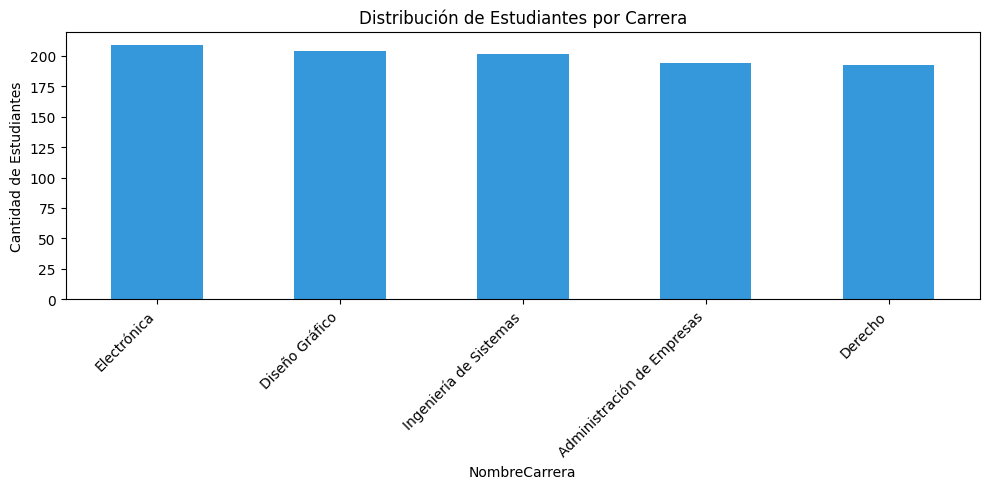

In [7]:
import matplotlib.pyplot as plt

query_distribucion = """
SELECT e.Ciudad, c.NombreCarrera
FROM Estudiantes e
JOIN Inscripciones i ON e.EstudianteID = i.EstudianteID
JOIN Carreras c ON i.CarreraID = c.CarreraID
"""

df_task1 = pd.read_sql(query_distribucion, conn)

# --- GRÁFICO 1: Por Carrera ---
plt.figure(figsize=(10, 5))
df_task1['NombreCarrera'].value_counts().plot(kind='bar', color='#3498db')
plt.title('Distribución de Estudiantes por Carrera')
plt.ylabel('Cantidad de Estudiantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


El análisis revela que la carrera con mayor concentración de estudiantes es Electronica, superando ampliamente a las demás. En cuanto a la distribución geográfica


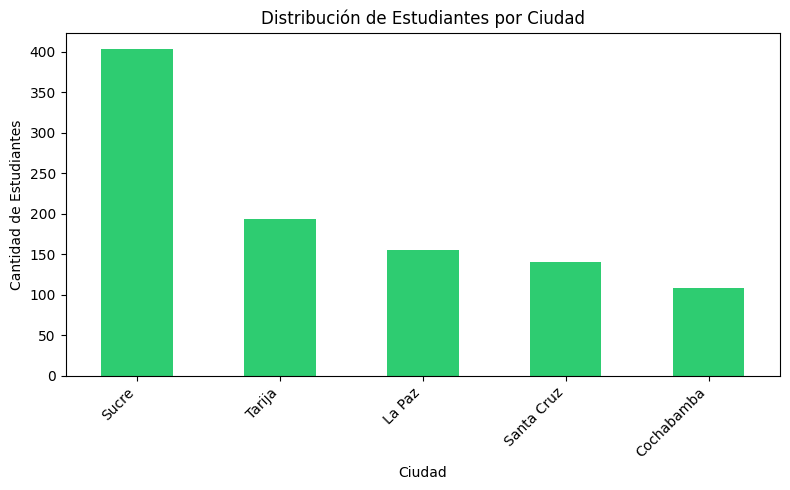

In [8]:
# --- GRÁFICO 2: Por Ciudad ---
plt.figure(figsize=(8, 5))
df_task1['Ciudad'].value_counts().plot(kind='bar', color='#2ecc71')
plt.title('Distribución de Estudiantes por Ciudad')
plt.ylabel('Cantidad de Estudiantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

En cuanto a la distribución geográfica, la ciudad de Ciudad Sucre concentra la mayor parte de la matrícula.